<a href="https://colab.research.google.com/github/kjesinthuyaUCLL/mbti-tune/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Mount Google Drive to access uploaded CSV files
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted successfully!")
print("Your files are at: /content/drive/MyDrive/mbti-tune-data/combined/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!
Your files are at: /content/drive/MyDrive/mbti-tune-data/combined/


In [2]:
# Cell 2: Install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn torch spotipy streamlit google-generativeai shap tqdm -q

print("✅ All packages installed!")

✅ All packages installed!


In [3]:
# Cell 3: Import all libraries we'll need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import files
import glob
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print("✅ All imports successful!")

Pandas version: 2.2.2
NumPy version: 2.0.2
✅ All imports successful!


In [4]:
# Cell 4: Find all CSV files in your Google Drive folder
data_path = "/content/drive/MyDrive/mbti-tune-data/combined/"

# Find all CSV files
csv_files = glob.glob(data_path + "*.csv")

print(f"Found {len(csv_files)} CSV files:")
print("-" * 50)
for file in csv_files:
    # Extract just the filename
    filename = os.path.basename(file)
    print(f"  📄 {filename}")

Found 16 CSV files:
--------------------------------------------------
  📄 ESTJ_songs.csv
  📄 ENFP_songs.csv
  📄 ESFP_songs.csv
  📄 INTJ_songs.csv
  📄 ESTP_songs.csv
  📄 ENFJ_songs.csv
  📄 ENTJ_songs.csv
  📄 INTP_songs.csv
  📄 ESFJ_songs.csv
  📄 ENTP_songs.csv
  📄 ISTP_songs.csv
  📄 ISFP_songs.csv
  📄 ISTJ_songs.csv
  📄 INFJ_songs.csv
  📄 INFP_songs.csv
  📄 ISFJ_songs.csv


In [5]:
# Cell 5: Examine structure of first CSV file
sample_file = csv_files[0]
df_sample = pd.read_csv(sample_file)

print(f"📁 File: {os.path.basename(sample_file)}")
print(f"📊 Shape: {df_sample.shape[0]} rows, {df_sample.shape[1]} columns")
print(f"\n📋 Column names:")
print(df_sample.columns.tolist())
print(f"\n🔍 First 3 rows:")
print(df_sample.head(3))
print(f"\n📊 Data types:")
print(df_sample.dtypes)

📁 File: ESTJ_songs.csv
📊 Shape: 1245 rows, 25 columns

📋 Column names:
['#', 'Song', 'Artist', 'BPM', 'Camelot', 'Energy', 'Added At', 'Duration', 'Popularity', 'Genres', 'Album', 'Album Date', 'Dance', 'Acoustic', 'Instrumental', 'Valence', 'Speech', 'Live', 'Loud (Db)', 'Key', 'Time Signature', 'Spotify Track Id', 'ISRC', 'appearance_count', 'mbti_type']

🔍 First 3 rows:
     #                Song            Artist  BPM Camelot  Energy    Added At  \
0   56     National Anthem      Lana Del Rey   85      5A      90  2021-11-12   
1  219  Are You Satisfied?            MARINA  124      8B      73  2025-05-31   
2    1          Pacify Her  Melanie Martinez  158      8A      59  2022-06-07   

  Duration  Popularity Genres  ... Valence Speech  Live  Loud (Db)      Key  \
0    03:50          61    NaN  ...      44     20    10         -6  C Minor   
1    03:21          66    NaN  ...      80      0     0         -5  C Major   
2    03:40          76    NaN  ...      37      0    20       

In [6]:
# Cell 6: Quick overview of all CSV files
file_info = []

for file in csv_files:
    df = pd.read_csv(file)
    filename = os.path.basename(file)

    # Try to extract MBTI type from filename
    mbti_type = filename.replace('_songs.csv', '')

    file_info.append({
        'filename': filename,
        'mbti_type': mbti_type,
        'rows': len(df),
        'columns': len(df.columns),
        'has_genres': 'Genres' in df.columns
    })

info_df = pd.DataFrame(file_info)
print("📊 All Files Overview:")
print(info_df.to_string())
print(f"\n✅ Total rows across all files: {info_df['rows'].sum()}")

📊 All Files Overview:
          filename mbti_type  rows  columns  has_genres
0   ESTJ_songs.csv      ESTJ  1245       25        True
1   ENFP_songs.csv      ENFP  3091       25        True
2   ESFP_songs.csv      ESFP  2429       25        True
3   INTJ_songs.csv      INTJ  2508       25        True
4   ESTP_songs.csv      ESTP  2457       25        True
5   ENFJ_songs.csv      ENFJ  2397       25        True
6   ENTJ_songs.csv      ENTJ  1570       25        True
7   INTP_songs.csv      INTP  2654       25        True
8   ESFJ_songs.csv      ESFJ  1811       25        True
9   ENTP_songs.csv      ENTP  1533       25        True
10  ISTP_songs.csv      ISTP  2875       25        True
11  ISFP_songs.csv      ISFP  5953       25        True
12  ISTJ_songs.csv      ISTJ  2086       25        True
13  INFJ_songs.csv      INFJ  3045       25        True
14  INFP_songs.csv      INFP  4891       25        True
15  ISFJ_songs.csv      ISFJ  3665       25        True

✅ Total rows across all f

In [7]:
# Cell 7: Check missing values in each file
missing_summary = []

for file in csv_files:
    df = pd.read_csv(file)
    filename = os.path.basename(file)

    missing_count = df.isnull().sum().sum()
    missing_pct = (missing_count / (df.shape[0] * df.shape[1])) * 100

    missing_summary.append({
        'file': filename,
        'total_missing': missing_count,
        'missing_percent': round(missing_pct, 2)
    })

missing_df = pd.DataFrame(missing_summary)
print("🔍 Missing Values Summary:")
print(missing_df.to_string())

🔍 Missing Values Summary:
              file  total_missing  missing_percent
0   ESTJ_songs.csv            591             1.90
1   ENFP_songs.csv           1103             1.43
2   ESFP_songs.csv            903             1.49
3   INTJ_songs.csv           1261             2.01
4   ESTP_songs.csv           1002             1.63
5   ENFJ_songs.csv            583             0.97
6   ENTJ_songs.csv            694             1.77
7   INTP_songs.csv           1116             1.68
8   ESFJ_songs.csv            571             1.26
9   ENTP_songs.csv            751             1.96
10  ISTP_songs.csv            969             1.35
11  ISFP_songs.csv           1943             1.31
12  ISTJ_songs.csv            677             1.30
13  INFJ_songs.csv           1373             1.80
14  INFP_songs.csv           1914             1.57
15  ISFJ_songs.csv           1416             1.55


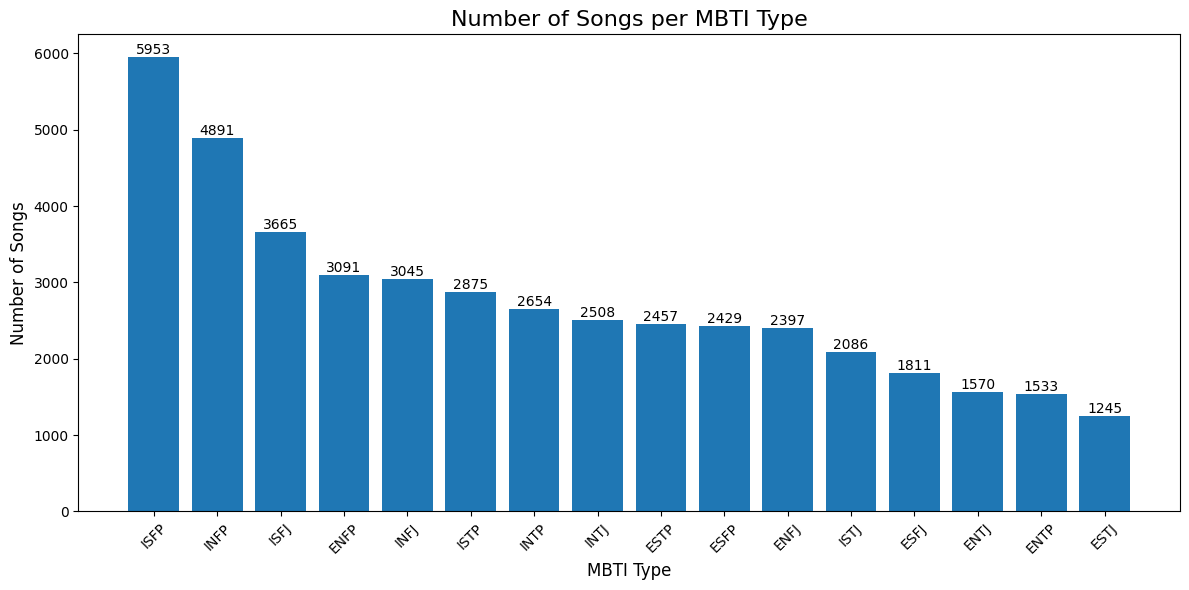


📊 Total songs: 44210

📊 Types found: 16


In [8]:
# Cell 8: Check which MBTI types we have and their counts
mbti_counts = []

for file in csv_files:
    df = pd.read_csv(file)
    filename = os.path.basename(file)

    # Get MBTI from filename (assuming format: ENFJ_songs.csv)
    mbti = filename.replace('_songs.csv', '')

    mbti_counts.append({
        'mbti_type': mbti,
        'song_count': len(df)
    })

counts_df = pd.DataFrame(mbti_counts).sort_values('song_count', ascending=False)

# Plot distribution
plt.figure(figsize=(12, 6))
bars = plt.bar(counts_df['mbti_type'], counts_df['song_count'])
plt.title('Number of Songs per MBTI Type', fontsize=16)
plt.xlabel('MBTI Type', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('/content/mbti_distribution.png')
plt.show()

print(f"\n📊 Total songs: {counts_df['song_count'].sum()}")
print(f"\n📊 Types found: {len(counts_df)}")

In [9]:
# Cell 9: Check which audio features are available in your data
# Based on your columns, you have these features:
expected_features = [
    'BPM', 'Energy', 'Dance', 'Acoustic', 'Instrumental',
    'Valence', 'Speech', 'Live', 'Loud (Db)', 'Key', 'Time Signature'
]

# Check actual columns from sample
sample_df = pd.read_csv(csv_files[0])
available_features = [f for f in expected_features if f in sample_df.columns]
missing_features = [f for f in expected_features if f not in sample_df.columns]

print("✅ Available audio features:")
for f in available_features:
    print(f"  - {f}")

if missing_features:
    print("\n⚠️ Missing features (will need to handle):")
    for f in missing_features:
        print(f"  - {f}")

print(f"\n📊 Total features available: {len(available_features)}")

✅ Available audio features:
  - BPM
  - Energy
  - Dance
  - Acoustic
  - Instrumental
  - Valence
  - Speech
  - Live
  - Loud (Db)
  - Key
  - Time Signature

📊 Total features available: 11


In [10]:
# Cell 10: Examine the Genres column format
sample_df = pd.read_csv(csv_files[0])

print("🔍 Genre column analysis:")
print(f"  Has 'Genres' column: {'Genres' in sample_df.columns}")

if 'Genres' in sample_df.columns:
    print(f"\n  Sample genres (first 5 rows):")
    for i, genres in enumerate(sample_df['Genres'].head(5)):
        print(f"    Row {i+1}: {genres}")

    # Check if genres are multiple per song (separated by commas)
    sample_genre = sample_df['Genres'].iloc[0]
    if ',' in str(sample_genre):
        print(f"\n  📌 Genres appear to be comma-separated lists")
        print(f"     Example split: {str(sample_genre).split(',')[:3]}")

🔍 Genre column analysis:
  Has 'Genres' column: True

  Sample genres (first 5 rows):
    Row 1: nan
    Row 2: nan
    Row 3: nan
    Row 4: dream pop
    Row 5: nan


In [11]:
# Cell 11: Define preprocessing function
def preprocess_mbti_data(csv_files, output_path='/content/processed_data/'):
    """
    Load all CSV files, merge them, and prepare for neural network
    """
    os.makedirs(output_path, exist_ok=True)

    all_data = []

    print("🔄 Loading and preprocessing files...")

    for file in tqdm(csv_files):
        df = pd.read_csv(file)
        filename = os.path.basename(file)

        # Extract MBTI type from filename
        mbti_type = filename.replace('_songs.csv', '')
        df['mbti_type'] = mbti_type

        # Add filename as source (for debugging)
        df['source_file'] = filename

        all_data.append(df)

    # Merge all data
    merged_df = pd.concat(all_data, ignore_index=True)

    print(f"\n✅ Merged data shape: {merged_df.shape}")

    # Drop duplicate songs (by Spotify Track Id if available)
    if 'Spotify Track Id' in merged_df.columns:
        before = len(merged_df)
        merged_df = merged_df.drop_duplicates(subset=['Spotify Track Id'])
        after = len(merged_df)
        print(f"   Removed {before - after} duplicate songs")

    # Save merged data
    merged_path = os.path.join(output_path, 'merged_songs.csv')
    merged_df.to_csv(merged_path, index=False)
    print(f"   Saved merged data to: {merged_path}")

    return merged_df

# Run preprocessing
merged_data = preprocess_mbti_data(csv_files)
print(f"\n📊 Final dataset: {len(merged_data)} unique songs")
print(f"📊 Columns: {merged_data.columns.tolist()}")

🔄 Loading and preprocessing files...


100%|██████████| 16/16 [00:00<00:00, 44.97it/s]



✅ Merged data shape: (44210, 26)
   Removed 12842 duplicate songs
   Saved merged data to: /content/processed_data/merged_songs.csv

📊 Final dataset: 31368 unique songs
📊 Columns: ['#', 'Song', 'Artist', 'BPM', 'Camelot', 'Energy', 'Added At', 'Duration', 'Popularity', 'Genres', 'Album', 'Album Date', 'Dance', 'Acoustic', 'Instrumental', 'Valence', 'Speech', 'Live', 'Loud (Db)', 'Key', 'Time Signature', 'Spotify Track Id', 'ISRC', 'appearance_count', 'mbti_type', 'source_file']


In [12]:
# Cell 12: Function to convert MBTI to 4 binary targets
def mbti_to_targets(mbti_type):
    """
    Convert MBTI string to 4 binary values

    Example: ENFJ -> [1, 1, 0, 1]
             ISTP -> [0, 0, 1, 0]
    """
    # First letter: E=1, I=0
    e_score = 1 if mbti_type[0] == 'E' else 0

    # Second letter: N=1, S=0
    n_score = 1 if mbti_type[1] == 'N' else 0

    # Third letter: T=1, F=0 (Note: T is 1, F is 0)
    t_score = 1 if mbti_type[2] == 'T' else 0

    # Fourth letter: J=1, P=0
    j_score = 1 if mbti_type[3] == 'J' else 0

    return [e_score, n_score, t_score, j_score]

# Test the function
test_types = ['ENFJ', 'INTJ', 'ISTP', 'ESFP', 'INFP']
print("Testing MBTI to targets conversion:")
for mbti in test_types:
    targets = mbti_to_targets(mbti)
    print(f"  {mbti} -> {targets} (E={targets[0]}, N={targets[1]}, T={targets[2]}, J={targets[3]})")

# Apply to all data
merged_data['targets'] = merged_data['mbti_type'].apply(mbti_to_targets)

# Split into separate columns
merged_data['E_score'] = merged_data['targets'].apply(lambda x: x[0])
merged_data['N_score'] = merged_data['targets'].apply(lambda x: x[1])
merged_data['T_score'] = merged_data['targets'].apply(lambda x: x[2])
merged_data['J_score'] = merged_data['targets'].apply(lambda x: x[3])

print(f"\n✅ Added target columns to dataset")
print(merged_data[['mbti_type', 'E_score', 'N_score', 'T_score', 'J_score']].head())

Testing MBTI to targets conversion:
  ENFJ -> [1, 1, 0, 1] (E=1, N=1, T=0, J=1)
  INTJ -> [0, 1, 1, 1] (E=0, N=1, T=1, J=1)
  ISTP -> [0, 0, 1, 0] (E=0, N=0, T=1, J=0)
  ESFP -> [1, 0, 0, 0] (E=1, N=0, T=0, J=0)
  INFP -> [0, 1, 0, 0] (E=0, N=1, T=0, J=0)

✅ Added target columns to dataset
  mbti_type  E_score  N_score  T_score  J_score
0      ESTJ        1        0        1        1
1      ESTJ        1        0        1        1
2      ESTJ        1        0        1        1
3      ESTJ        1        0        1        1
4      ESTJ        1        0        1        1


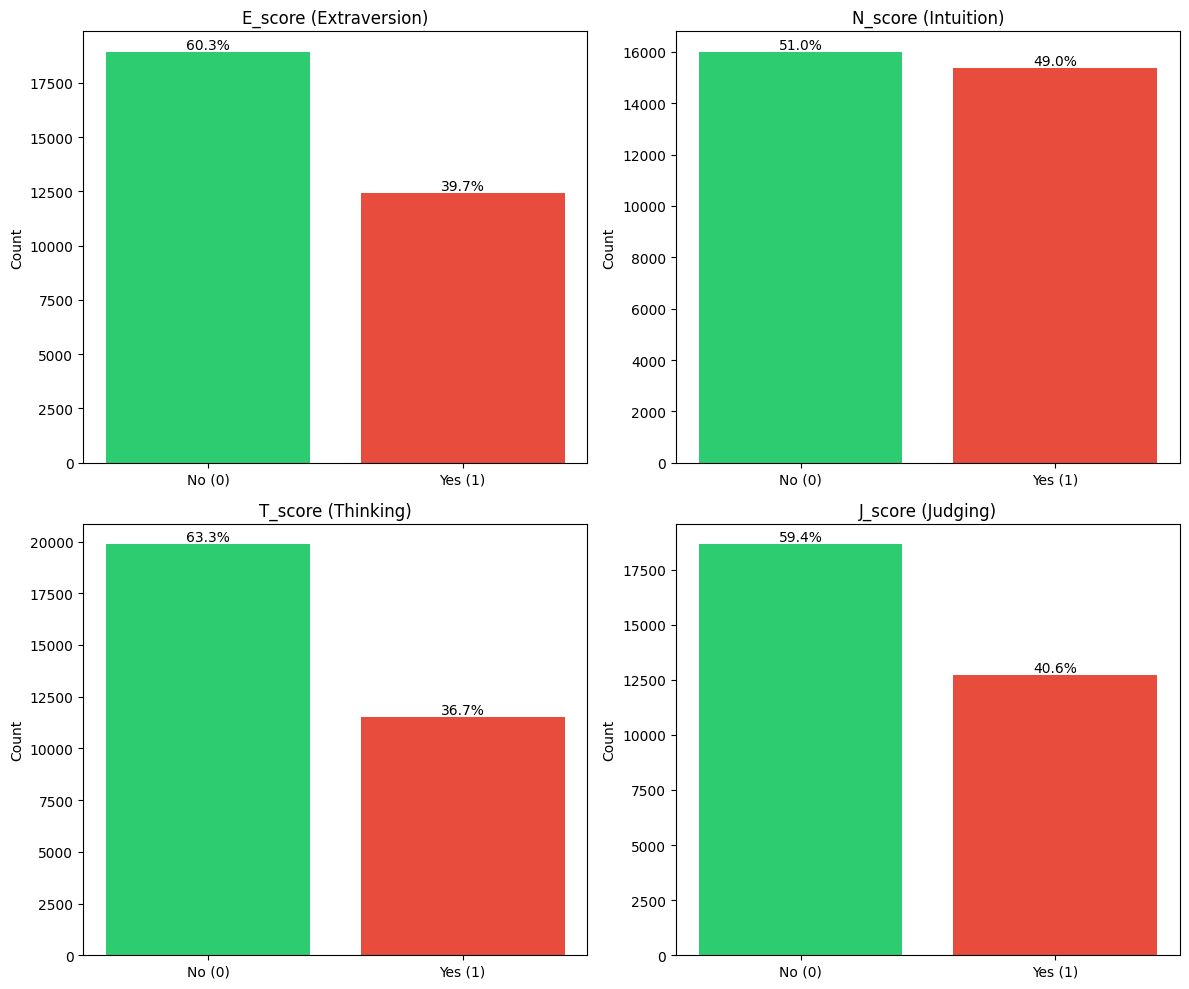

📊 Dimension balance analysis:
  E_score (Extraversion): Yes=39.7%, No=60.3%
  N_score (Intuition): Yes=49.0%, No=51.0%
  T_score (Thinking): Yes=36.7%, No=63.3%
  J_score (Judging): Yes=40.6%, No=59.4%


In [13]:
# Cell 13: Check distribution of each MBTI dimension
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

dimensions = ['E_score (Extraversion)', 'N_score (Intuition)', 'T_score (Thinking)', 'J_score (Judging)']

for idx, (dim, ax) in enumerate(zip(dimensions, axes.flatten())):
    values = merged_data[dim.split()[0]].value_counts()
    labels = ['Yes (1)' if v == 1 else 'No (0)' for v in values.index]
    colors = ['#2ecc71', '#e74c3c']
    ax.bar(labels, values.values, color=colors)
    ax.set_title(dim, fontsize=12)
    ax.set_ylabel('Count')

    # Add percentage labels
    total = values.sum()
    for i, (label, count) in enumerate(zip(labels, values.values)):
        pct = (count/total)*100
        ax.text(i, count, f'{pct:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('/content/dimension_distribution.png')
plt.show()

print("📊 Dimension balance analysis:")
for dim in dimensions:
    positive_pct = (merged_data[dim.split()[0]] == 1).mean() * 100
    negative_pct = 100 - positive_pct
    print(f"  {dim}: Yes={positive_pct:.1f}%, No={negative_pct:.1f}%")

In [14]:
# Cell 14: Save train/validation/test splits
from sklearn.model_selection import train_test_split

# Define features to use (only numeric audio features)
feature_cols = [col for col in available_features if col in merged_data.columns]
print(f"Using {len(feature_cols)} features: {feature_cols}")

# Prepare X and y
X = merged_data[feature_cols].copy()
y = merged_data[['E_score', 'N_score', 'T_score', 'J_score']].copy()

# Handle any missing values (fill with median)
for col in X.columns:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col].fillna(median_val, inplace=True)
        print(f"  Filled missing values in {col} with median: {median_val}")

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=merged_data['mbti_type'])
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=X_temp.index.map(lambda i: merged_data.loc[i, 'mbti_type']))

print(f"\n📊 Data splits:")
print(f"  Training:   {len(X_train)} songs")
print(f"  Validation: {len(X_val)} songs")
print(f"  Test:       {len(X_test)} songs")

# Save splits
X_train.to_csv('/content/processed_data/X_train.csv', index=False)
X_val.to_csv('/content/processed_data/X_val.csv', index=False)
X_test.to_csv('/content/processed_data/X_test.csv', index=False)
y_train.to_csv('/content/processed_data/y_train.csv', index=False)
y_val.to_csv('/content/processed_data/y_val.csv', index=False)
y_test.to_csv('/content/processed_data/y_test.csv', index=False)

print("\n✅ Saved all splits to /content/processed_data/")

# Also save to Google Drive for backup
!cp -r /content/processed_data /content/drive/MyDrive/mbti_tune_data/
print("✅ Backed up to Google Drive")

Using 11 features: ['BPM', 'Energy', 'Dance', 'Acoustic', 'Instrumental', 'Valence', 'Speech', 'Live', 'Loud (Db)', 'Key', 'Time Signature']

📊 Data splits:
  Training:   21957 songs
  Validation: 4705 songs
  Test:       4706 songs

✅ Saved all splits to /content/processed_data/
✅ Backed up to Google Drive


In [16]:
# Cell 15: Display summary statistics
print("\n" + "="*50)
print("📊 PROJECT DATA SUMMARY")
print("="*50)
print(f"Total songs: {len(merged_data)}")
print(f"MBTI types: {merged_data['mbti_type'].nunique()}")
print(f"Audio features: {len(feature_cols)}")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")


📊 PROJECT DATA SUMMARY
Total songs: 31368
MBTI types: 16
Audio features: 11
Training samples: 21957
Validation samples: 4705
Test samples: 4706
